In [28]:
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq
import matplotlib.pyplot as plt

# FASE 1: Caso empresarial

Sector: agroexportadora.

Ingresos: USD 500.000 mensuales durante 12 meses (cobranza de exportaciones)

Costos operativos: ARS (salarios, logística, insumos) — estimados en el equivalente a USD 300.000/mes al tipo de cambio vigente

Exposición neta: la empresa tiene un flujo positivo en USD que necesita convertir parcialmente a ARS para cubrir costos, pero está expuesta a que una apreciación del peso (o restricciones cambiarias) reduzca su margen en términos reales

Horizonte del swap: 12 meses, pagos mensuales

# FASE 2: Datos

In [29]:
tc = pd.read_csv("C://Program1/Proyectos/Github/Cobertura Cambiaria con Swap de Divisas/DOLAR OFICIAL - Cotizaciones historicas.csv")
mep = pd.read_csv("C:/Program1/Proyectos/Github/Cobertura Cambiaria con Swap de Divisas/DOLAR MEP - Cotizaciones historicas.csv")
ccl = pd.read_csv("C:/Program1/Proyectos/Github/Cobertura Cambiaria con Swap de Divisas/DOLAR CCL - Cotizaciones historicas.csv")
badlar = pd.read_csv("C:/Program1/Proyectos/Github/Cobertura Cambiaria con Swap de Divisas/BADLAR - Cotizaciones historicas.csv")

#tasas
lecaps = pd.read_excel("C:/Program1/Proyectos/Github/Cobertura Cambiaria con Swap de Divisas/curva_lecaps_1a12meses.xlsx")
sofr = pd.read_csv("C:/Program1/Proyectos/Github/Cobertura Cambiaria con Swap de Divisas/tasas_sofr_18_09_2026.csv")

In [30]:
lecaps

,Ticker,Plazo Estimado,Vencimiento,Dias al Vto,Precio Regular ($),TNA (%),TEM (%),TEA (%)
0,S30S6L,1 Mes,30/09/2026,9,1.1692,21.46,1.10,23.86
1,S16O6L,1 Mes,16/10/2026,25,1.0365,22.92,1.64,25.54
2,S30O6L,1.5 Meses,30/10/2026,39,1.3230,21.07,1.57,23.16
3,S13N6L,2 Meses,13/11/2026,53,1.0597,23.92,1.84,26.51
4,S30N6L,2.5 Meses,30/11/2026,70,1.2422,23.82,1.85,26.23
5,T15E7B,4 Meses,15/01/2027,116,149.1400,25.07,1.90,26.48
6,S29E7L,4.5 Meses,29/01/2027,130,1.0260,24.87,1.93,26.91
7,T30A7B,7 Meses,30/04/2027,221,155.2000,26.10,2.15,28.59
8,T31Y7B,8 Meses,31/05/2027,252,158.4000,26.80,2.20,29.73
9,T30J7B,9 Meses,30/06/2027,282,162.1000,26.50,2.18,28.90


Excluir S30S6, rompe monotonicidad de la curva de tasas por entrar en el plazo ultra corto (9 días al vencimiento y su precio ya está "quemado")

In [31]:
lecaps = lecaps[~lecaps["Ticker"].isin(["S30S6L"])].reset_index(drop=True)

Mismo indice para el resto

In [32]:
tc      = tc.set_index("fecha")
mep     = mep.set_index("fecha")
ccl     = ccl.set_index("fecha")
badlar  = badlar.set_index("fecha")

Corregimos las fechas

In [33]:
for frame in [tc, mep, ccl, badlar]:
    frame.index = pd.to_datetime(frame.index)

Interpolamos para las tasas LECAP/BONCAP de la curva

In [34]:
lecaps

,Ticker,Plazo Estimado,Vencimiento,Dias al Vto,Precio Regular ($),TNA (%),TEM (%),TEA (%)
0,S16O6L,1 Mes,16/10/2026,25,1.0365,22.92,1.64,25.54
1,S30O6L,1.5 Meses,30/10/2026,39,1.3230,21.07,1.57,23.16
2,S13N6L,2 Meses,13/11/2026,53,1.0597,23.92,1.84,26.51
3,S30N6L,2.5 Meses,30/11/2026,70,1.2422,23.82,1.85,26.23
4,T15E7B,4 Meses,15/01/2027,116,149.1400,25.07,1.90,26.48
5,S29E7L,4.5 Meses,29/01/2027,130,1.0260,24.87,1.93,26.91
6,T30A7B,7 Meses,30/04/2027,221,155.2000,26.10,2.15,28.59
7,T31Y7B,8 Meses,31/05/2027,252,158.4000,26.80,2.20,29.73
8,T30J7B,9 Meses,30/06/2027,282,162.1000,26.50,2.18,28.90
9,TY30P,12 Meses,30/09/2027,374,175.8000,27.20,2.24,30.39


In [35]:
#Días al vencimiento 
dias = np.array(lecaps["Dias al Vto"])

tea = np.array(lecaps["TEA (%)"]/100)
#Descuentos
df_obs = (1 + tea) ** (-dias / 365)

#interpolar sobre log (mayor estabilidad)
log_df = np.log(df_obs)
cs = CubicSpline(dias, log_df)

# Nodos mensuales (30, 60, 90, ..., 365)
dias_swap = np.array([30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 365])
df_swap = np.exp(cs(dias_swap))

# Reconvertir a TEA para control visual
tea_swap_lecap = df_swap ** (-365 / dias_swap) - 1
tea_swap_lecap

array([0.22493364, 0.26737611, 0.25892043, 0.2661143 , 0.27209995,
       0.27468323, 0.28148103, 0.29460063, 0.29405311, 0.28073365,
       0.27420962, 0.29272699])

Idem para SOFR

In [36]:
sofr

,Indicador,Plazo,Tasa_Porcentaje,Fecha_Valor,Fuente
0,CME Term SOFR,360,4.46092,18/9/2026,global-rates.com (CME Group)
1,CME Term SOFR,180,4.18790,18/9/2026,global-rates.com (CME Group)
2,CME Term SOFR,90,4.02325,18/9/2026,global-rates.com (CME Group)
3,SOFR Overnight,30,3.85000,17/9/2026,global-rates.com (Federal Reserve)


In [37]:
#Días al vencimiento 
dias = np.array(sofr["Plazo"].iloc[::-1].values)

tea = np.array(sofr["Tasa_Porcentaje"].iloc[::-1].values/100)
#Descuentos
df_obs = (1 + tea) ** (-dias / 365)

#interpolar sobre log (mayor estabilidad)
log_df = np.log(df_obs)
cs = CubicSpline(dias, log_df)

# Nodos mensuales (30, 60, 90, ..., 365)
dias_swap = np.array([30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 365])
df_swap = np.exp(cs(dias_swap))

# Reconvertir a TEA para control visual
tea_swap_sofr = df_swap ** (-365 / dias_swap) - 1
tea_swap_sofr

array([0.0385    , 0.03954553, 0.0402325 , 0.04082145, 0.04136449,
       0.041879  , 0.0423724 , 0.0428484 , 0.04330906, 0.04375561,
       0.04418882, 0.04467804])

Realizamos Dataframes para tasas y precios

In [38]:
tasas = pd.DataFrame({"Plazo": dias_swap, "TEA Lecaps": tea_swap_lecap, "TEA SOFR": tea_swap_sofr}).set_index("Plazo")
tasas["df_ars"] = (1 + tasas["TEA Lecaps"]) ** (-tasas.index / 365)
tasas["df_usd"] = (1 + tasas["TEA SOFR"])  ** (-tasas.index / 365)
tasas

,TEA Lecaps,TEA SOFR,df_ars,df_usd
Plazo,,,,
30,0.224934,0.038500,0.983463,0.996900
60,0.267376,0.039546,0.961798,0.993645
90,0.258920,0.040232,0.944807,0.990321
120,0.266114,0.040821,0.925359,0.986932
150,0.272100,0.041364,0.905829,0.983481
180,0.274683,0.041879,0.887198,0.979971
210,0.281481,0.042372,0.867019,0.976406
240,0.294601,0.042848,0.843853,0.972790
270,0.294053,0.043309,0.826392,0.969124


In [39]:
df = pd.concat([
    tc[["cierre"]].rename(columns={"cierre": "tc_oficial"}),
    mep[["cierre"]].rename(columns={"cierre": "mep"}),
    ccl[["cierre"]].rename(columns={"cierre": "ccl"}),
    badlar[["cierre"]].rename(columns={"cierre": "badlar"}),
], axis=1).dropna()
df.tail()

,tc_oficial,mep,ccl,badlar
fecha,,,,
2026-09-14,1530.0,1534.10,1593.64,21.4375
2026-09-15,1530.0,1532.45,1596.74,22.1250
2026-09-16,1535.0,1537.56,1595.91,22.5625
2026-09-17,1535.0,1533.83,1594.06,22.7500
2026-09-18,1535.0,1538.32,1587.52,22.0625


# FASE 3: Flujos sin cobertura

Excel manual ("proyecciones.xlsx")

# FASE 4: Curva de tipo de cambio

Los forward se calculan:
F = S * [(1+tasa_ars)/(1+tasa_usd)]**T
Con S el tipo de cambio (CCL) spot

In [40]:
S = df["ccl"].iloc[-1]
F = S * ((1+tasas["TEA Lecaps"])/(1+tasas["TEA SOFR"]))**((tasas.index)/365)
forwards = pd.DataFrame({"forwards":F})
forwards

,forwards
Plazo,
30,1609.210487
60,1640.085102
90,1663.996381
120,1693.152965
150,1723.610472
180,1753.524355
210,1787.809561
240,1830.085139
270,1861.712128


Curva creciente

In [ ]:
#Prima de cobertura implícita (costo anualizado de cubrirse)
prima = (forwards["forwards"] / S - 1) * (365 / forwards.index)
df_prima = pd.DataFrame({"prima": prima})
print(prima)

#TC spot vs forward a 12 meses
print(f"TC spot CCL:       {S:.2f}")
print(f"Forward 12 meses:  {forwards['forwards'].iloc[-1]:.2f}")
print(f"Depreciación impl: {(forwards['forwards'].iloc[-1]/S - 1)*100:.1f}%")

Plazo
30     0.166235
60     0.201428
90     0.195370
120    0.202391
150    0.208598
180    0.212041
210    0.219287
240    0.232376
270    0.233488
300    0.222819
330    0.218128
365    0.237441
dtype: float64
TC spot CCL:       1587.52
Forward 12 meses:  1964.46
Depreciación impl: 23.7%


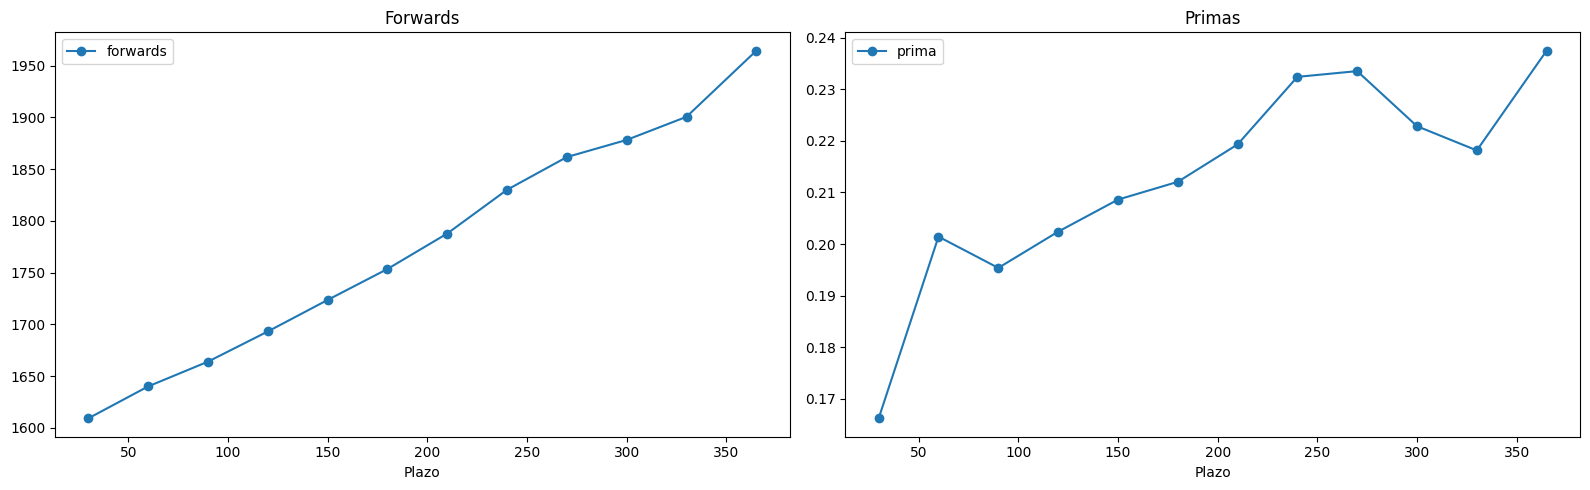

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
forwards.plot(y= "forwards", ax=ax[0], marker="o", title="Forwards")
df_prima.plot(y= "prima", ax=ax[1], marker="o", title="Primas")
plt.tight_layout()
plt.show()


# FASE 5: Diseño del Swap

In [43]:
N_usd = 500_000
N_ars = 500_000 * S #ultimo tipo de cambio ccl
fd_usd = tasas["df_usd"]
fd_ars = tasas["df_ars"]
c_usd = tasas["TEA SOFR"].iloc[-1] #sofr anual
delta_t = np.diff(np.concatenate([[0], dias_swap])) / 365 #ajusta por fracion de tiempo (sin esto daria una tasa mensual)
#buscamos tasa c_ars
def npv_swap(c_ars):
    ARS = np.sum((c_ars*N_ars*fd_ars*delta_t))+N_ars*fd_ars.iloc[-1]
    USD = N_usd * S # pata USD a par cuando c_USD = SOFR
    return ARS - USD

c_ars = brentq(npv_swap, 0.01, 2)
print(f"Tasa fija swap ARS: {c_ars:.4%}")

Tasa fija swap ARS: 25.8266%


# FASE 6: Valuacion de Swap

Por portafolio de forwards:

In [44]:
K_t = forwards["forwards"].values #tipo de cambio acordado
V_portafolio = np.sum((forwards["forwards"].values - K_t)*N_usd*fd_ars.values)
print(f"El valor del Swap es: {round(V_portafolio,3)} ARS")

El valor del Swap es: 0.0 ARS


Por diferencia de bonos:

In [45]:
delta_t = np.diff(np.concatenate([[0], dias_swap])) / 365
B_usd = N_usd 
#np.sum(c_usd * N_usd * delta_t * fd_usd) + N_usd * fd_usd.iloc[-1] al usar de simplificacion la SOFR a 1 año para todos los períodos, el bono queda ligeramente sobre la par.
B_ars = np.sum(c_ars*N_ars*delta_t*fd_ars) + N_ars * fd_ars.iloc[-1]

V_bonos = B_usd * S - B_ars

print(f"B_USD (en USD):     {B_usd:,.2f}")
print(f"B_USD (en ARS):     {B_usd * S:,.2f}")
print(f"B_ARS (en ARS):     {B_ars:,.2f}")
print(f"V_swap (Método 2):  {V_bonos:,.2f}")

B_USD (en USD):     500,000.00
B_USD (en ARS):     793,760,000.00
B_ARS (en ARS):     793,760,000.00
V_swap (Método 2):  0.00


# FASE 7: Modelo de flujo de caja con cobertura y análisis comparativo

Realizado en Excel

# FASE 8: Stress test y sensibilidad

In [ ]:
shocks_bps = [-1000, -500, 0, 500, 1000]
delta_t = np.diff(np.concatenate([[0], dias_swap])) / 365
resultados = []
for shock in shocks_bps:
    tea_shocked = tasas["TEA Lecaps"]+shock/10000
    fd_ars_shocked = (1 + tea_shocked) ** (-dias_swap / 365) #factores de descuento
    
    B_ars_shocked = np.sum(c_ars*N_ars*delta_t*fd_ars_shocked) + N_ars * fd_ars_shocked.iloc[-1]
    V_swap_shocked = B_usd*S - B_ars_shocked
    
    resultados.append({"shock_bps": shock, "V_swap": V_swap_shocked})

stress = pd.DataFrame(resultados).set_index("shock_bps")
print(stress)

                 V_swap
shock_bps              
-1000     -5.929715e+07
-500      -2.847963e+07
 0         0.000000e+00
 500       2.640043e+07
 1000      5.094344e+07


Ante tasas bajas el swap tiene valor negativo, lo que resulta desfavorable para la empresa
Caso contrario, para tasas altas, el valor es positivo, y por tanto favorable a la empresa

Tasas bajas causan un descuento menor del valor futuro (mayor valor presente, mayor valor de bono) y viceversa

Ponderación del TC forward promedio

In [47]:
F = np.sum(forwards["forwards"]*fd_ars)/np.sum(fd_ars)
costo_cobertura = (F / S - 1)

print(f"TC spot CCL:               {S:.2f}")
print(f"TC forward promedio pond.: {F:.2f}")
print(f"Costo de cobertura:        {costo_cobertura:.2%}")
# divide por ~6 meses promedio ponderado de duración

TC spot CCL:               1587.52
TC forward promedio pond.: 1767.59
Costo de cobertura:        11.34%
